# 13. Hybrid Model: SARIMAX + GRU Residual Learner

## Kiến trúc
```
PM2.5_t+24  ≈  SARIMAX_linear(t)  +  GRU_nonlinear(residual_t)
```

**Chiến lược huấn luyện không rò rỉ dữ liệu (Leak-Free):**
1. **Stage 1 – Cố định SARIMAX**: Lấy dự báo SARIMAX đã lưu từ notebook 9 (`tuned_stats_preds_real_units.pkl`).
   - Residual `ε_t = y_real_t – SARIMAX_pred_t` được tính riêng cho từng tập Train / Val.
   - **Không có dữ liệu rò rỉ**: SARIMAX được fit hoàn toàn trên Train trước khi sinh ra residual.
2. **Stage 2 – Huấn luyện GRU trên Residual**: GRU nhận thêm các đặc trưng thời tiết/lag để dự báo `ε_t`.
   - Dữ liệu train = (X_train, ε_train); dữ liệu val = (X_val, ε_val).
   - Test residual **không bao giờ được nhìn thấy** trong quá trình huấn luyện.
3. **Stage 3 – Kết hợp cuối cùng**: `ŷ_hybrid = SARIMAX_pred + GRU_pred_residual`.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid", context="notebook")

# ── Paths (notebook-safe: works both in /notebooks and project root) ──
NB_DIR   = Path("").resolve()
ROOT     = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
PRED_DIR = ROOT / "outputs" / "predictions"
FIG_DIR  = ROOT / "outputs" / "figures"
DATA_DIR = ROOT / "data" / "processed_R" / "modeling_fs"
PRED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LOG = "target_pm25_h24_log"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true > 1e-6
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

# ── Load feature matrices ──
def load_split(fname):
    df  = pd.read_csv(DATA_DIR / fname, parse_dates=["datetime_local"])
    feat = [c for c in df.columns if c not in ("datetime_local", TARGET_LOG)]
    return df[feat].values.astype(np.float32), np.expm1(df[TARGET_LOG].values.astype(np.float32)), df

X_train, y_train_real, df_train = load_split("train_dl.csv")
X_val,   y_val_real,   df_val   = load_split("val_dl.csv")
X_test,  y_test_real,  df_test  = load_split("test_dl.csv")

num_features = X_train.shape[1]
print(f"Features: {num_features}  |  Train: {len(y_train_real)}  |  Val: {len(y_val_real)}  |  Test: {len(y_test_real)}")


Features: 26  |  Train: 6383  |  Val: 2128  |  Test: 2128


## 1. Lấy Dự Báo SARIMAX (Stage-1 Already Trained)

Dùng thẳng kết quả pkl đã được tạo từ notebook 9 để đảm bảo **không tái huấn luyện SARIMAX** trong notebook này,
giữ nguyên tính chất không rò rỉ (walk-forward 24-step).


In [3]:
with open(PRED_DIR / "tuned_stats_preds_real_units.pkl", "rb") as f:
    stats_preds = pickle.load(f)

sarimax_train = np.array(stats_preds["sarimax"]["train"], dtype=np.float32)
sarimax_val   = np.array(stats_preds["sarimax"]["val"],   dtype=np.float32)
sarimax_test  = np.array(stats_preds["sarimax"]["test"],  dtype=np.float32)

# Tính residuals (real units)
# Đây là phần phi tuyến mà SARIMAX chưa nắm bắt được
resid_train = y_train_real - sarimax_train   # shape (6383,)
resid_val   = y_val_real   - sarimax_val     # shape (2128,)

print("SARIMAX Test RMSE (baseline):")
print(regression_metrics(y_test_real, sarimax_test))

print(f"\nResidual stats (Train) – Mean: {resid_train.mean():.3f}, Std: {resid_train.std():.3f}")
print(f"Residual stats (Val)   – Mean: {resid_val.mean():.3f}, Std: {resid_val.std():.3f}")


SARIMAX Test RMSE (baseline):
{'RMSE': 17.399429663992105, 'MAE': 11.963019033123675, 'MAPE': np.float64(30.98456677511007)}

Residual stats (Train) – Mean: 0.545, Std: 6.571
Residual stats (Val)   – Mean: 2.594, Std: 14.403


## 2. Xây Dựng GRU Residual Learner

GRU nhận **toàn bộ đặc trưng thời tiết / lag** để học phần phi tuyến còn lại.
Input = X (features), Target = ε (SARIMAX residual).


In [4]:
class ResidualGRU(nn.Module):
    """
    BiGRU (best architecture from nb10 grid search) adapted to predict SARIMAX residuals.
    Input shape: (batch, seq_len=1, num_features)
    Output: scalar residual estimate.
    """
    def __init__(self, input_size, hidden_size=64, num_layers=1,
                 bidirectional=True, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        fc_in = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Sequential(
            nn.Linear(fc_in, fc_in // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_in // 2, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])  # last time-step


class EarlyStopper:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = float("inf")

    def step(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

print("Model classes defined.")


Model classes defined.


In [5]:
BATCH = 64

def make_loader(X_np, y_np, shuffle=False):
    X_t = torch.tensor(X_np, dtype=torch.float32).unsqueeze(1)  # (N,1,F)
    y_t = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)  # (N,1)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH, shuffle=shuffle), X_t

# Residual = target for GRU
train_loader, X_tr_t = make_loader(X_train, resid_train)
val_loader,   X_v_t  = make_loader(X_val,   resid_val)
_, X_te_t            = make_loader(X_test,  np.zeros(len(X_test)))  # test X only

print("DataLoaders created.")


DataLoaders created.


## 3. Huấn Luyện GRU Residual Learner

Sử dụng kiến trúc BiGRU(64, 1-layer) — cùng winner từ Grid Search notebook 10.
KRẻ hơn nhưng học residual nhỏ nên ít cần capacity.


In [6]:
def train_gru(model, train_loader, val_loader,
              epochs=100, lr=5e-4, patience=12):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    stopper   = EarlyStopper(patience=patience)
    model.to(device)

    history = {"train": [], "val": []}
    best_state = None
    best_val   = float("inf")

    for epoch in range(1, epochs + 1):
        # ── train ──
        model.train()
        t_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item() * Xb.size(0)
        t_loss /= len(train_loader.dataset)

        # ── val ──
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                v_loss += criterion(model(Xb), yb).item() * Xb.size(0)
        v_loss /= len(val_loader.dataset)

        scheduler.step(v_loss)
        history["train"].append(t_loss)
        history["val"].append(v_loss)

        if v_loss < best_val:
            best_val   = v_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}/{epochs} | Train MSE: {t_loss:.5f} | Val MSE: {v_loss:.5f}")

        if stopper.step(v_loss):
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def predict_gru(model, X_tensor):
    model.eval()
    return model(X_tensor.to(device)).cpu().numpy().flatten()


# ── Instantiate & Train ──
t0 = time.time()
gru_model = ResidualGRU(input_size=num_features, hidden_size=64,
                        num_layers=1, bidirectional=True, dropout=0.1)
gru_model, history = train_gru(gru_model, train_loader, val_loader,
                               epochs=120, lr=5e-4, patience=12)
print(f"\nTraining hoàn tất sau {time.time()-t0:.1f}s")


Epoch  10/120 | Train MSE: 42.01140 | Val MSE: 209.82764



Early stopping at epoch 19.

Training hoàn tất sau 17.0s


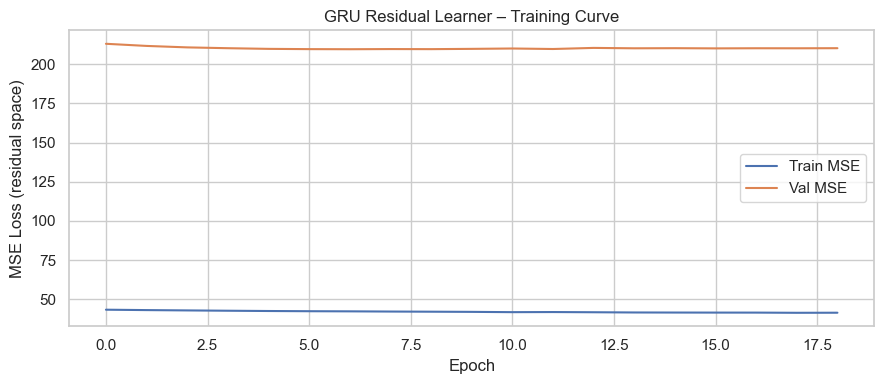

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history["train"], label="Train MSE")
ax.plot(history["val"],   label="Val MSE")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (residual space)")
ax.set_title("GRU Residual Learner – Training Curve")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "hybrid_gru_training_curve.png", dpi=150)
plt.show()


## 4. Kết Hợp & Đánh Giá Hybrid Model
`ŷ_hybrid = SARIMAX_pred + GRU_residual_pred`


In [8]:
# GRU residual predictions
gru_resid_train = predict_gru(gru_model, X_tr_t)
gru_resid_val   = predict_gru(gru_model, X_v_t)
gru_resid_test  = predict_gru(gru_model, X_te_t)

# Hybrid = SARIMAX + GRU residual
hybrid_train = sarimax_train + gru_resid_train
hybrid_val   = sarimax_val   + gru_resid_val
hybrid_test  = sarimax_test  + gru_resid_test

# ── Metrics on all splits ──
results = {}
for split, yt, yp_sarimax, yp_hybrid in [
    ("Train", y_train_real, sarimax_train, hybrid_train),
    ("Val",   y_val_real,   sarimax_val,   hybrid_val),
    ("Test",  y_test_real,  sarimax_test,  hybrid_test),
]:
    sarimax_m = regression_metrics(yt, yp_sarimax)
    hybrid_m  = regression_metrics(yt, yp_hybrid)
    results[split] = {"SARIMAX": sarimax_m, "Hybrid": hybrid_m}

df_results = pd.DataFrame([
    {"Split": sp, "Model": m, **metrics}
    for sp, models in results.items()
    for m, metrics in models.items()
])
print(df_results.round(4).to_string(index=False))


Split   Model    RMSE     MAE    MAPE
Train SARIMAX  6.5940  4.1853 13.4319
Train  Hybrid  6.4966  4.0715 13.4458
  Val SARIMAX 14.6343 10.6209 42.0695
  Val  Hybrid 14.4775 10.5311 42.4208
 Test SARIMAX 17.3994 11.9630 30.9846
 Test  Hybrid 17.2437 11.8945 31.2431


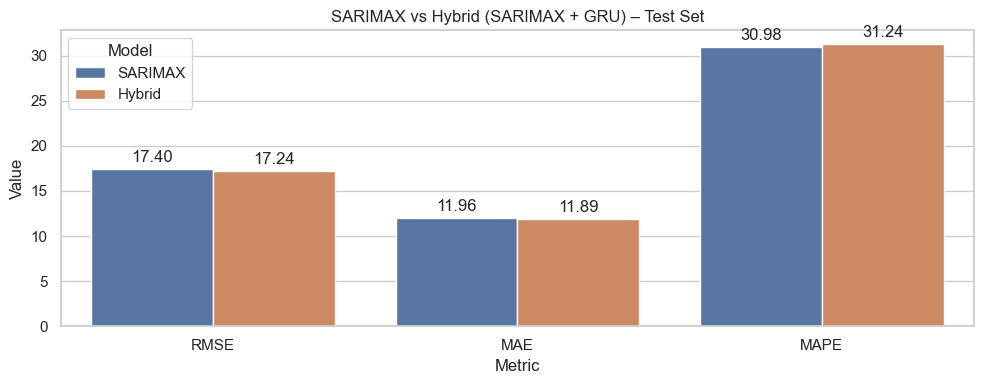

In [9]:
# ── Bar chart comparison ──
test_df_plot = df_results[df_results["Split"] == "Test"].melt(
    id_vars=["Model"], value_vars=["RMSE", "MAE", "MAPE"],
    var_name="Metric", value_name="Value"
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=test_df_plot, x="Metric", y="Value", hue="Model", ax=ax)
ax.set_title("SARIMAX vs Hybrid (SARIMAX + GRU) – Test Set")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.tight_layout()
plt.savefig(FIG_DIR / "hybrid_vs_sarimax_bar.png", dpi=150)
plt.show()


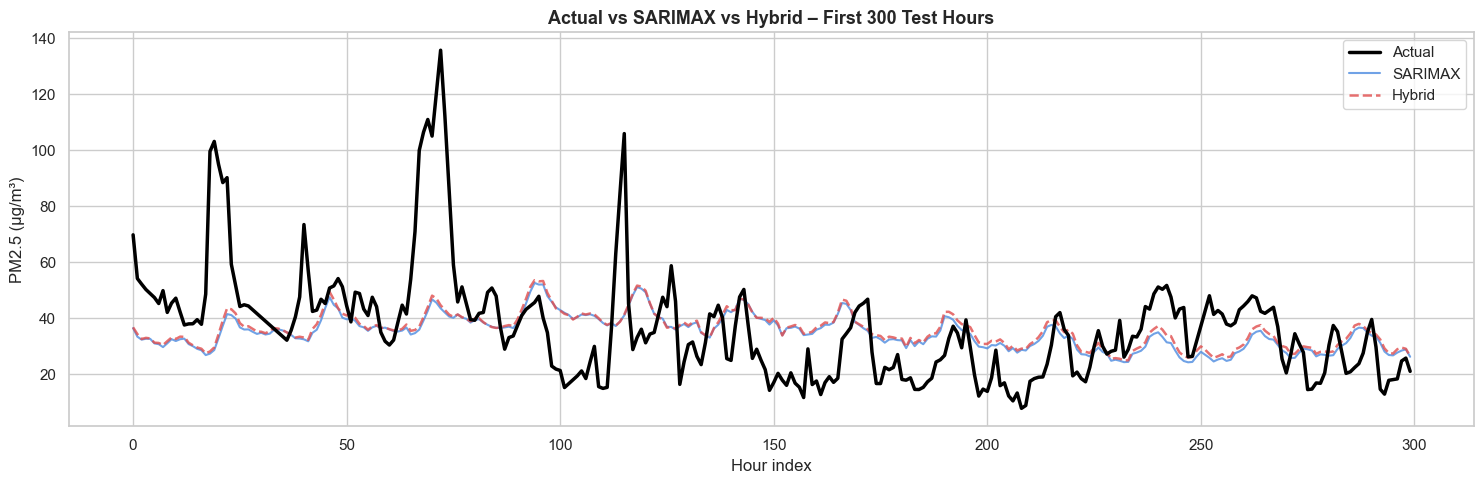

In [10]:
# ── Time-series overlay (first 300 test hours) ──
N = 300
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(y_test_real[:N],    label="Actual",     color="black", lw=2.5, zorder=5)
ax.plot(sarimax_test[:N],   label="SARIMAX",    color="#4C8BE0", alpha=0.8, lw=1.5)
ax.plot(hybrid_test[:N],    label="Hybrid",     color="#E04C4C", alpha=0.8, lw=1.8, ls="--")
ax.set_title("Actual vs SARIMAX vs Hybrid – First 300 Test Hours", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour index"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "hybrid_vs_sarimax_ts.png", dpi=150)
plt.show()


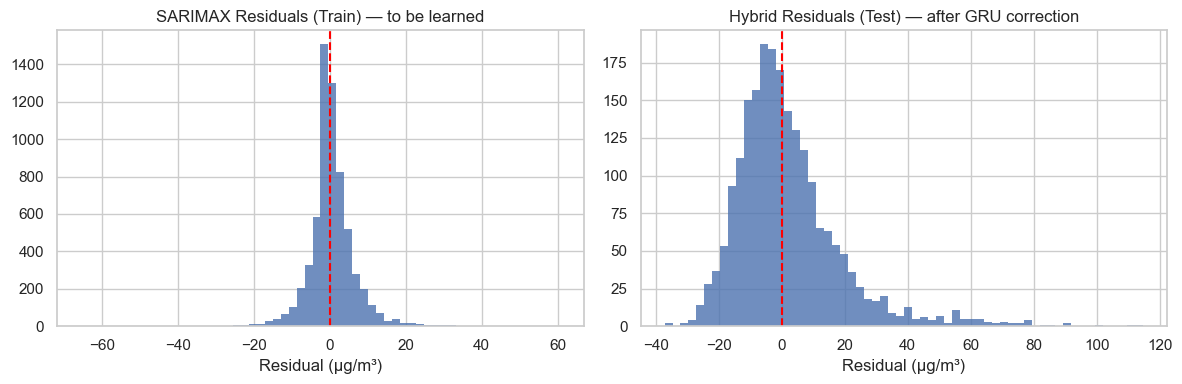

In [11]:
# ── Residual distribution before & after ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, resid, title in [
    (axes[0], resid_train, "SARIMAX Residuals (Train) — to be learned"),
    (axes[1], y_test_real - hybrid_test, "Hybrid Residuals (Test) — after GRU correction"),
]:
    ax.hist(resid, bins=60, edgecolor="none", alpha=0.8)
    ax.axvline(0, color="red", ls="--")
    ax.set_title(title)
    ax.set_xlabel("Residual (µg/m³)")
plt.tight_layout()
plt.savefig(FIG_DIR / "hybrid_residual_dist.png", dpi=150)
plt.show()


## 5. Scatter Plot: Actual vs. Predicted
Đánh giá tính hiệu chỉnh (calibration) của mô hình.


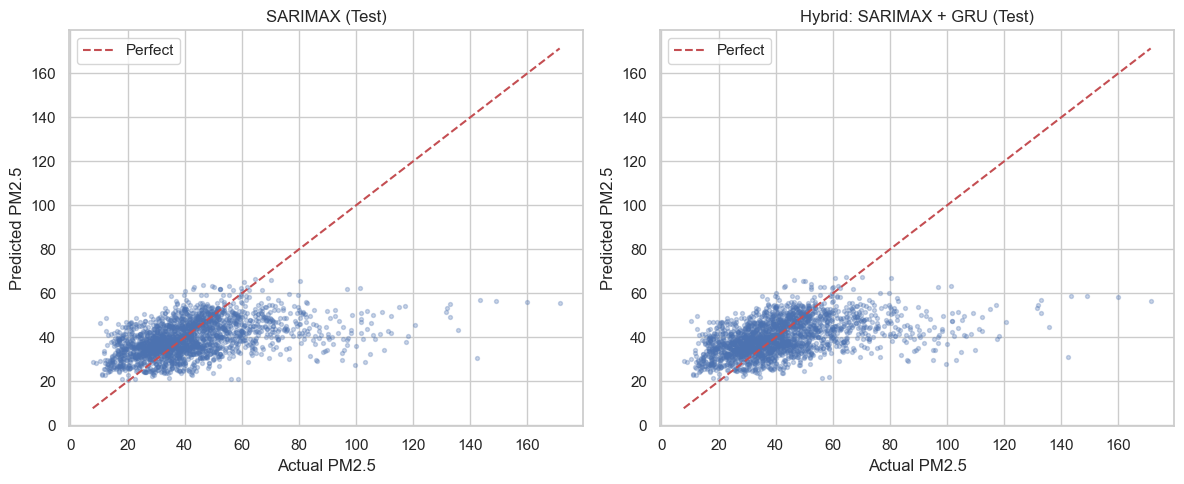

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ypred, title in [
    (axes[0], sarimax_test, "SARIMAX (Test)"),
    (axes[1], hybrid_test,  "Hybrid: SARIMAX + GRU (Test)"),
]:
    ax.scatter(y_test_real, ypred, alpha=0.3, s=8)
    lim = [min(y_test_real.min(), ypred.min()), max(y_test_real.max(), ypred.max())]
    ax.plot(lim, lim, 'r--', lw=1.5, label="Perfect")
    ax.set_xlabel("Actual PM2.5"); ax.set_ylabel("Predicted PM2.5")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "hybrid_scatter.png", dpi=150)
plt.show()


## 6. Export Kết Quả

In [13]:
hybrid_export = {
    "hybrid_sarimax_gru": {
        "train": hybrid_train,
        "val":   hybrid_val,
        "test":  hybrid_test,
        "note":  "Real-unit µg/m³. SARIMAX walk-forward 24h + BiGRU residual"
    }
}
with open(PRED_DIR / "hybrid_sarimax_gru_preds.pkl", "wb") as f:
    pickle.dump(hybrid_export, f, protocol=pickle.HIGHEST_PROTOCOL)

df_test_metrics = df_results[df_results["Split"] == "Test"].round(4)
df_test_metrics.to_csv(PRED_DIR / "hybrid_test_metrics.csv", index=False)

print("Saved predictions -> hybrid_sarimax_gru_preds.pkl")
print("Saved metrics     -> hybrid_test_metrics.csv")
print("\n=== Final Test Metrics ===")
display(df_test_metrics.reset_index(drop=True))


Saved predictions -> hybrid_sarimax_gru_preds.pkl
Saved metrics     -> hybrid_test_metrics.csv

=== Final Test Metrics ===


,Split,Model,RMSE,MAE,MAPE
0,Test,SARIMAX,17.3994,11.9630,30.9846
1,Test,Hybrid,17.2437,11.8945,31.2431
